# Exp2 Real Delayed Conversion Logs Result Check

Rendered result check with CSV previews and embedded PNG figures. This notebook reads existing outputs only.

In [1]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

rows = []
for name in ['README.md','requirements.txt','reproduce_fast.py','reproduce_full.py','reproduce_paper.py','code_check.py','self_check.py','output_manifest.md','docs','outputs','runlogs']:
    rows.append({'path': name, 'exists': (ROOT/name).exists()})
display(pd.DataFrame(rows))
missing = [row['path'] for row in rows if not row['exists'] and row['path'] in {'README.md','outputs'}]
if missing:
    display(Markdown('Warning: required display/interface paths missing: ' + ', '.join(missing)))
else:
    display(Markdown('Required GitHub display paths are present.'))


,path,exists
0,README.md,True
1,requirements.txt,True
2,reproduce_fast.py,True
3,reproduce_full.py,True
4,reproduce_paper.py,True
5,code_check.py,True
6,self_check.py,True
7,output_manifest.md,True
8,docs,True
9,outputs,True


Required GitHub display paths are present.

In [2]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

csvs = prefer_outputs(find_files(['outputs/**/summaries/*.csv','outputs/**/summary/*.csv','outputs/**/tables/*.csv','outputs/**/checks/*.csv','outputs/**/metadata/*.csv']))
display(Markdown(f'Found `{len(csvs)}` CSV/table/check/metadata files. Showing selected previews.'))
for path in csvs[:6]:
    show_dataframe(path)


Found `49` CSV/table/check/metadata files. Showing selected previews.

**outputs/full/checks/code_check_report.csv**

,check_name,status,detail
0,all_python_files_compile,PASS,30 files
1,mode_isolation,PASS,runner clears isolated outputs/<mode>
2,missing_input_hard_failure,PASS,missing protected input exits non-zero
3,all_conversion_main_cohort,PASS,all conversion candidates use source-time deci...
4,source_linked_audit_only,PASS,source-linked reference is restricted by seman...
5,uid_bootstrap,PASS,UID-cluster percentile bootstrap implemented
6,main_figure_contract,PASS,main figure displays delay composition plus ho...
7,appendix_pairwise_overlap_figure,PASS,appendix uses pairwise TV and top-10 overlap h...


Rows: `23` | Columns: `3`

**outputs/full/checks/exp2_self_check_results.csv**

...

,route,method_display_name,reference_route,reference_label,top_k,cost_lambda,n_eligible_conversion_events,top_k_credited_mass_per_1000_events,top_k_cost_adjusted_score_per_1000_events,top_k_credited_mass_difference_per_1000_events_vs_arrival_anchor,...,credit_allocation_tv_distance_vs_arrival_anchor_ci_lower,credit_allocation_tv_distance_vs_arrival_anchor_ci_upper,top_k_decision_cell_overlap_vs_arrival_anchor_ci_lower,top_k_decision_cell_overlap_vs_arrival_anchor_ci_upper,spearman_rank_correlation_vs_arrival_anchor_ci_lower,spearman_rank_correlation_vs_arrival_anchor_ci_upper,ci_level,candidate_window_days,window_common_cohort_events,common_cohort_coverage
0,arrival_bin_anchor,Arrival-bin anchor (diagnostic),arrival_bin_anchor,arrival_anchor,10,0.0,85142.0,350.426347,350.426347,0.000000,...,0.000000,0.000000,1.0,1.0,1.000000,1.000000,0.95,1.0,85142,1.00000
1,first_click,First click or touch,arrival_bin_anchor,arrival_anchor,10,0.0,85142.0,56.998896,56.998896,-293.427451,...,0.939133,0.942571,0.0,0.0,0.095892,0.112108,0.95,1.0,85142,1.00000
2,last_click,Last click or touch,arrival_bin_anchor,arrival_anchor,10,0.0,85142.0,56.928425,56.928425,-293.497921,...,0.939101,0.942431,0.0,0.0,0.095877,0.112355,0.95,1.0,85142,1.00000
3,linear_attribution,Linear attribution,arrival_bin_anchor,arrival_anchor,10,0.0,85142.0,56.963661,56.963661,-293.462686,...,0.939089,0.942475,0.0,0.0,0.096106,0.112408,0.95,1.0,85142,1.00000
4,time_decay_soft,Time-decay attribution,arrival_bin_anchor,arrival_anchor,10,0.0,85142.0,56.953924,56.953924,-293.472423,...,0.939087,0.942454,0.0,0.0,0.096271,0.112255,0.95,1.0,85142,1.00000
5,soft_attribution_em,EM soft attribution,arrival_bin_anchor,arrival_anchor,10,0.0,85142.0,56.969521,56.969521,-293.456826,...,0.939074,0.942436,0.0,0.0,0.096320,0.112164,0.95,1.0,85142,1.00000
6,arrival_bin_anchor,Arrival-bin anchor (diagnostic),arrival_bin_anchor,arrival_anchor,10,0.0,85142.0,350.426347,350.426347,0.000000,...,0.000000,0.000000,1.0,1.0,1.000000,1.000000,0.95,7.0,85142,0.67639
7,first_click,First click or touch,arrival_bin_anchor,arrival_anchor,10,0.0,85142.0,57.868032,57.868032,-292.558314,...,0.941405,0.944956,0.0,0.0,0.089320,0.104930,0.95,7.0,85142,0.67639


Rows: `24` | Columns: `30`

**outputs/full/summaries/exp2_cost_adjusted_credit_score.csv**

,route,method_display_name,reference_route,reference_label,top_k,cost_lambda,n_eligible_conversion_events,top_k_credited_mass_per_1000_events,top_k_cost_adjusted_score_per_1000_events,top_k_credited_mass_difference_per_1000_events_vs_arrival_anchor,top_k_cost_adjusted_score_difference_per_1000_events_vs_arrival_anchor,credit_allocation_tv_distance_vs_arrival_anchor,top_k_decision_cell_overlap_vs_arrival_anchor,spearman_rank_correlation_vs_arrival_anchor,top_action_id,top_action_score
0,arrival_bin_anchor,Arrival-bin anchor (diagnostic),arrival_bin_anchor,arrival_anchor,10,0.1,145248.0,336.548524,270.670578,0.000000,0.000000,0.000000,1.0,1.000000,378,0.362684
1,first_click,First click or touch,arrival_bin_anchor,arrival_anchor,10,0.1,145248.0,38.602941,22.216066,-297.945583,-248.454512,0.924371,0.0,0.923783,45,0.126658
2,last_click,Last click or touch,arrival_bin_anchor,arrival_anchor,10,0.1,145248.0,40.936880,22.396987,-295.611644,-248.273591,0.922243,0.0,0.934436,545,0.110715
3,linear_attribution,Linear attribution,arrival_bin_anchor,arrival_anchor,10,0.1,145248.0,36.902079,20.682874,-299.646445,-249.987704,0.923484,0.0,0.931591,545,0.112882
4,time_decay_soft,Time-decay attribution,arrival_bin_anchor,arrival_anchor,10,0.1,145248.0,37.781172,20.891186,-298.767352,-249.779392,0.922515,0.0,0.933901,545,0.111160
5,soft_attribution_em,EM soft attribution,arrival_bin_anchor,arrival_anchor,10,0.1,145248.0,37.847588,20.957602,-298.700936,-249.712976,0.922434,0.0,0.933724,545,0.111692
6,arrival_bin_anchor,Arrival-bin anchor (diagnostic),arrival_bin_anchor,arrival_anchor,10,0.5,145248.0,264.244602,136.856976,0.000000,0.000000,0.000000,1.0,1.000000,378,0.271147
7,first_click,First click or touch,arrival_bin_anchor,arrival_anchor,10,0.5,145248.0,8.605970,-6.051170,-255.638632,-142.908145,0.924371,0.0,0.984752,189,-0.024960


Rows: `18` | Columns: `16`

Found `4` PNG figure files. Showing selected embedded figures.

**outputs/full/figures/png/fig_app_exp2_source_route_pairwise_overlap.png**

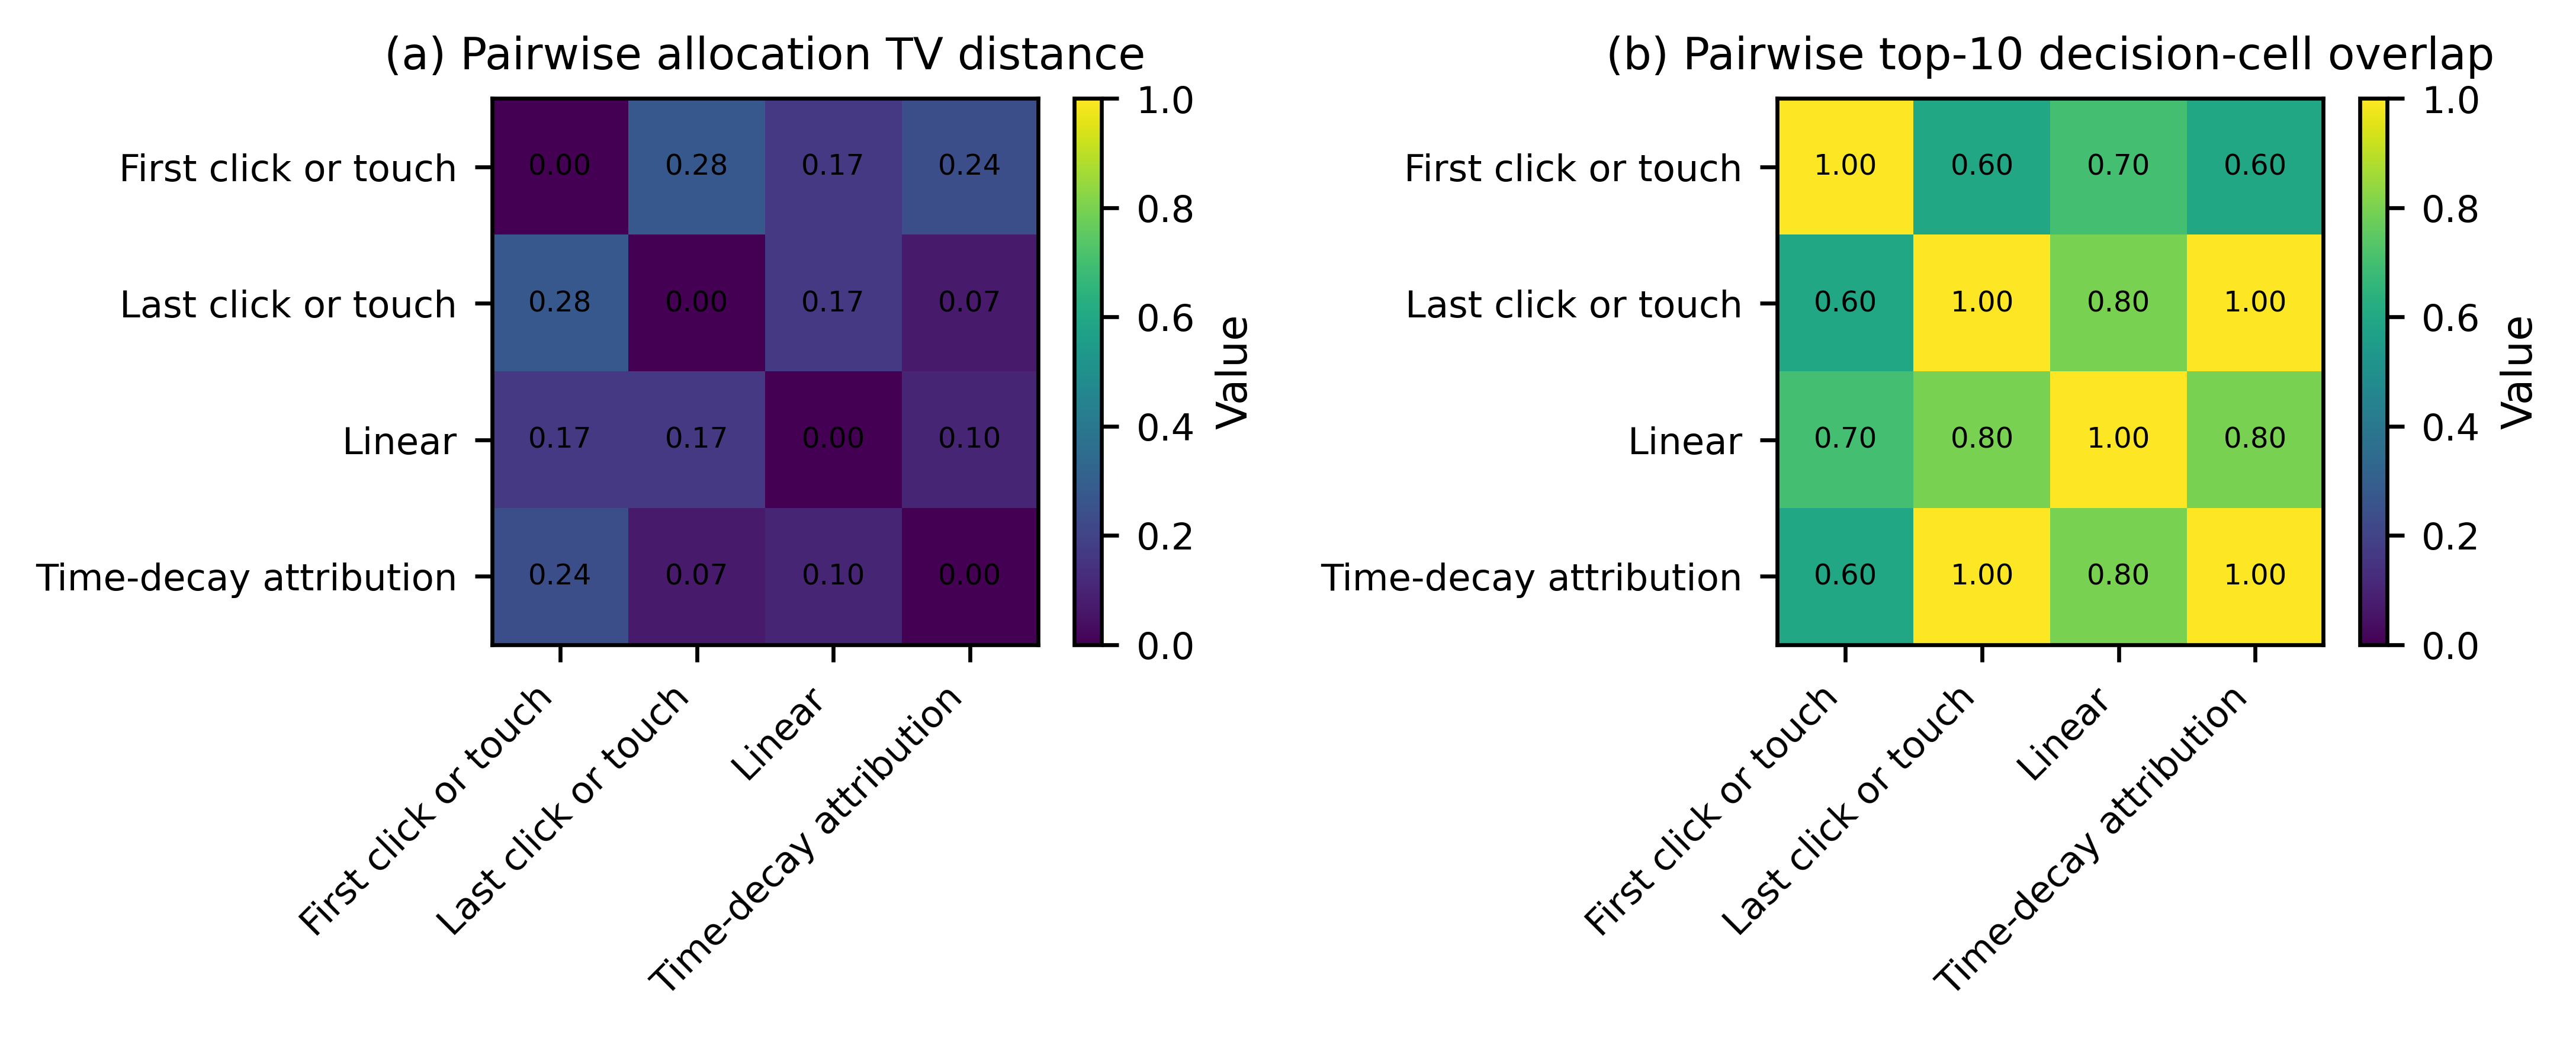

**outputs/full/figures/png/fig_exp2_attribution_sensitivity.png**

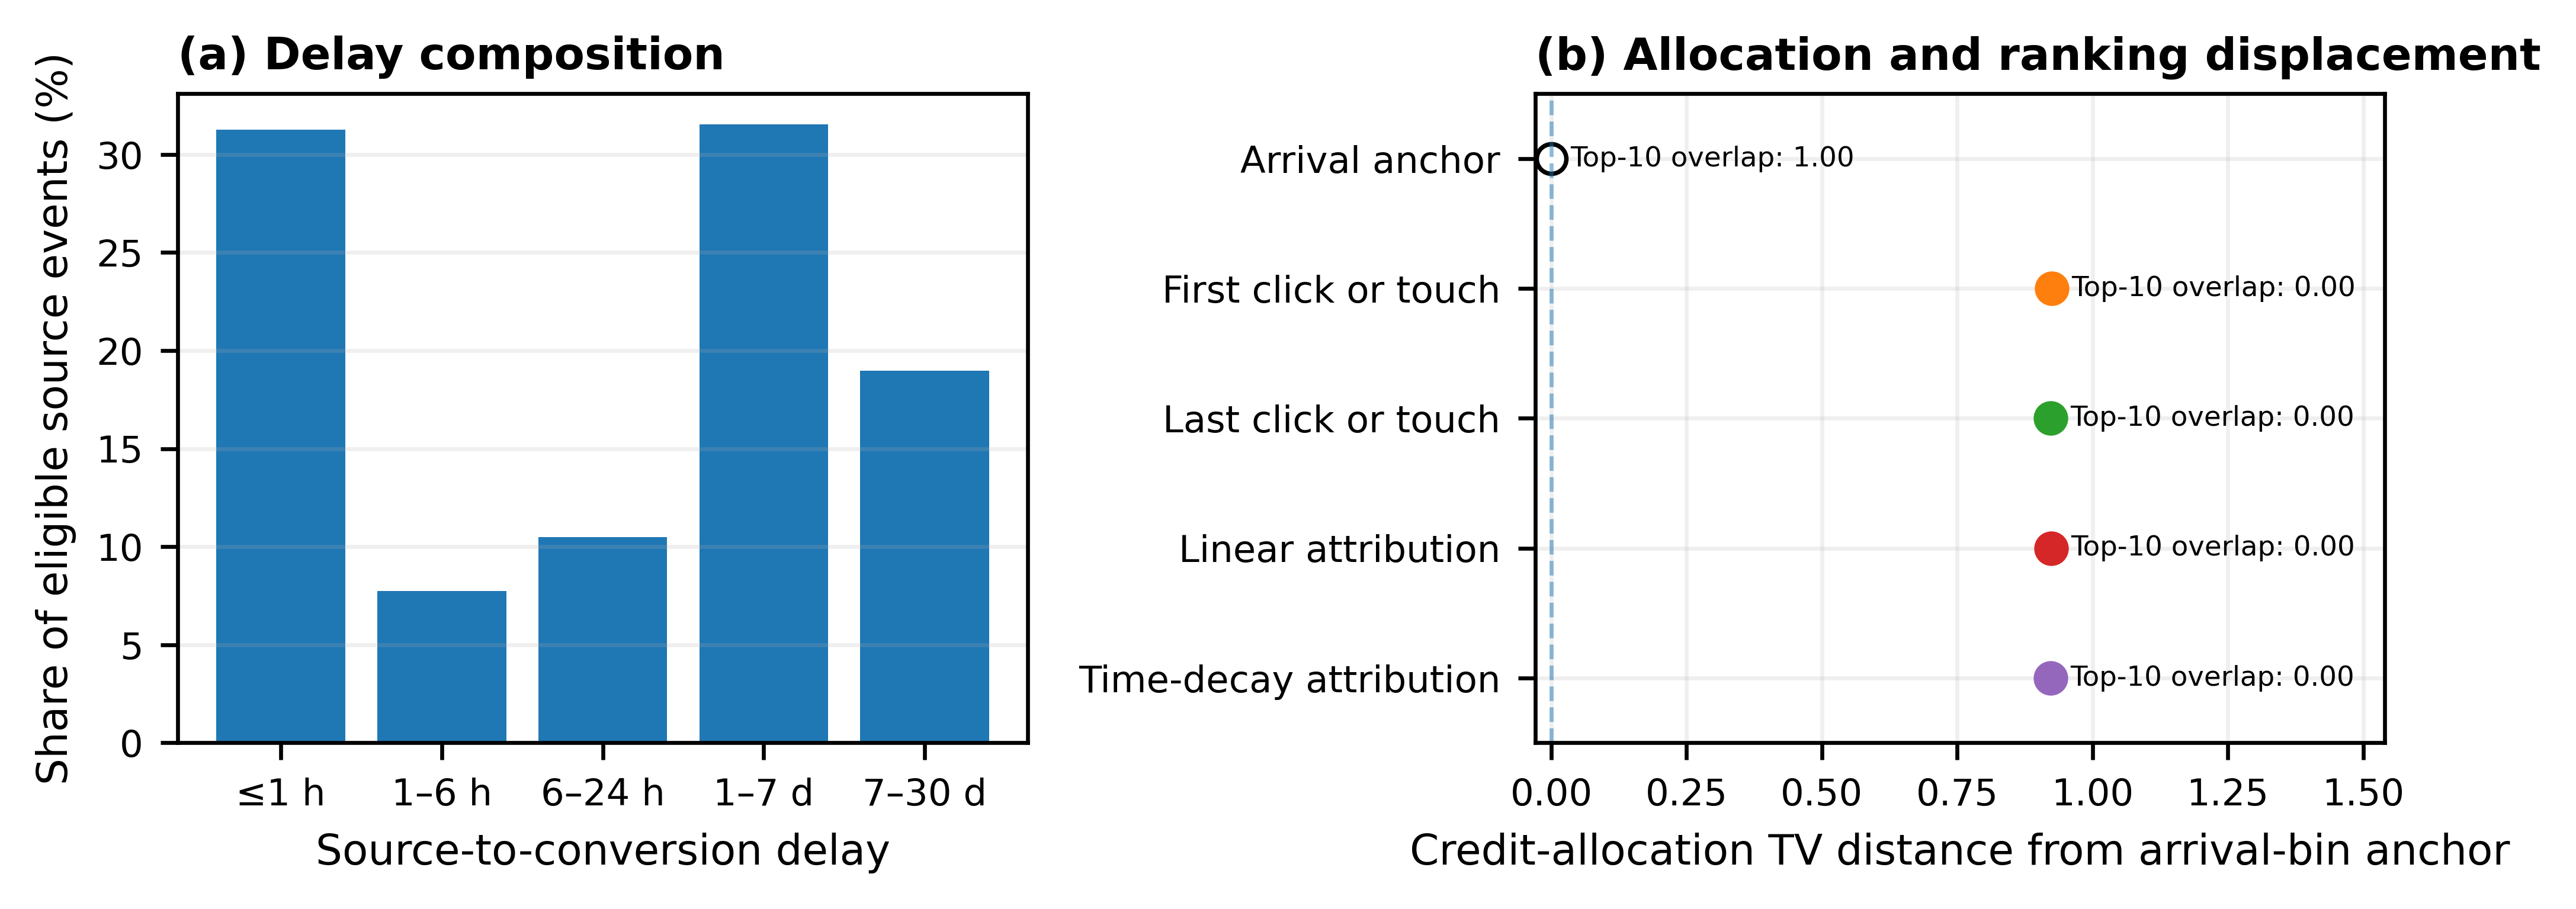

**outputs/fast/figures/png/fig_app_exp2_source_route_pairwise_overlap.png**

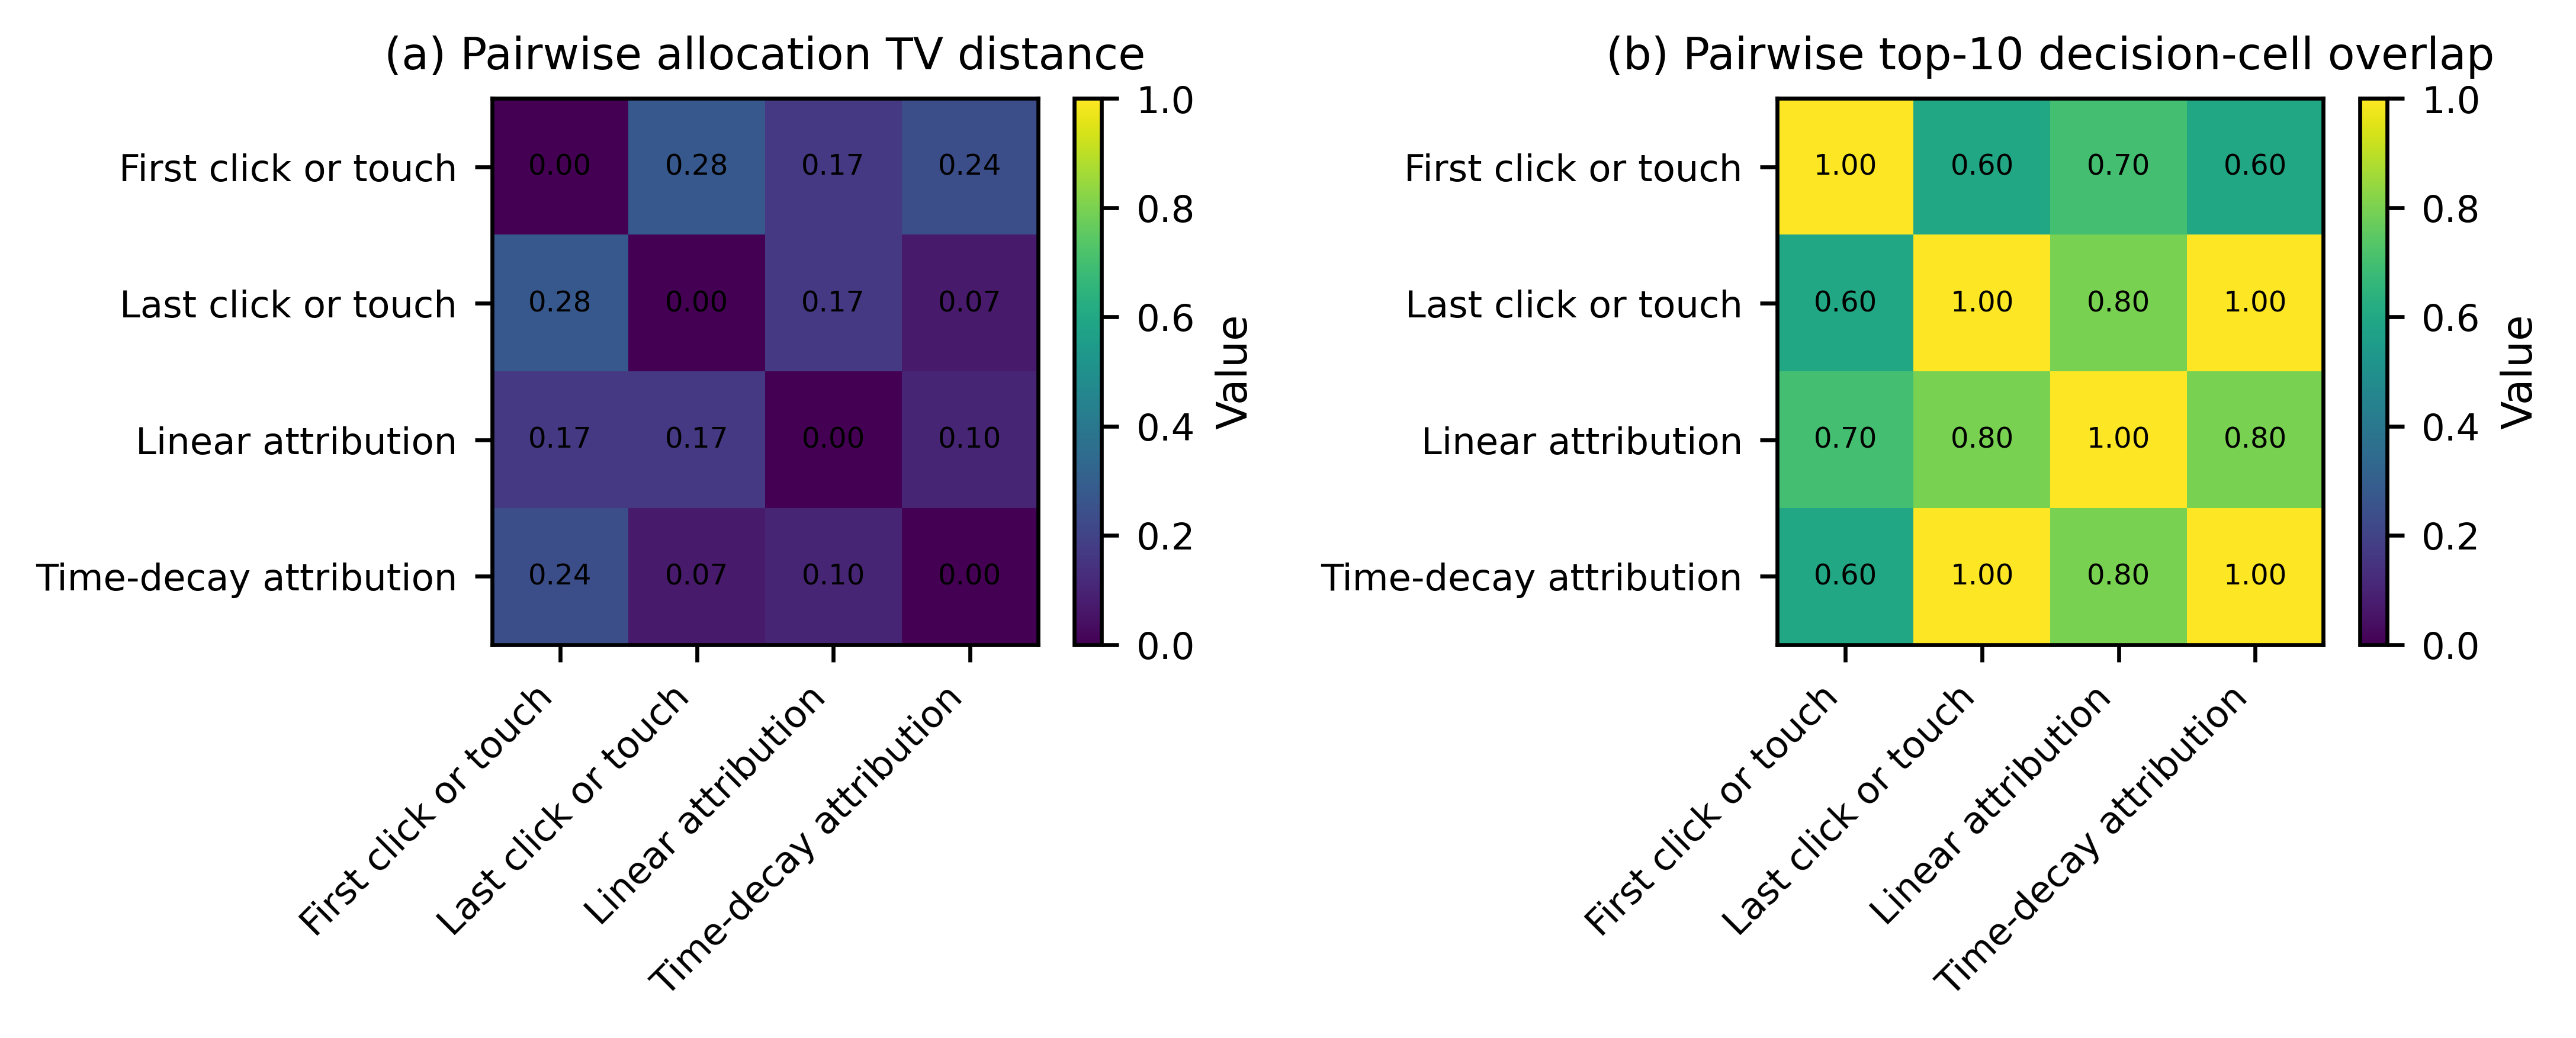

**outputs/fast/figures/png/fig_exp2_attribution_sensitivity.png**

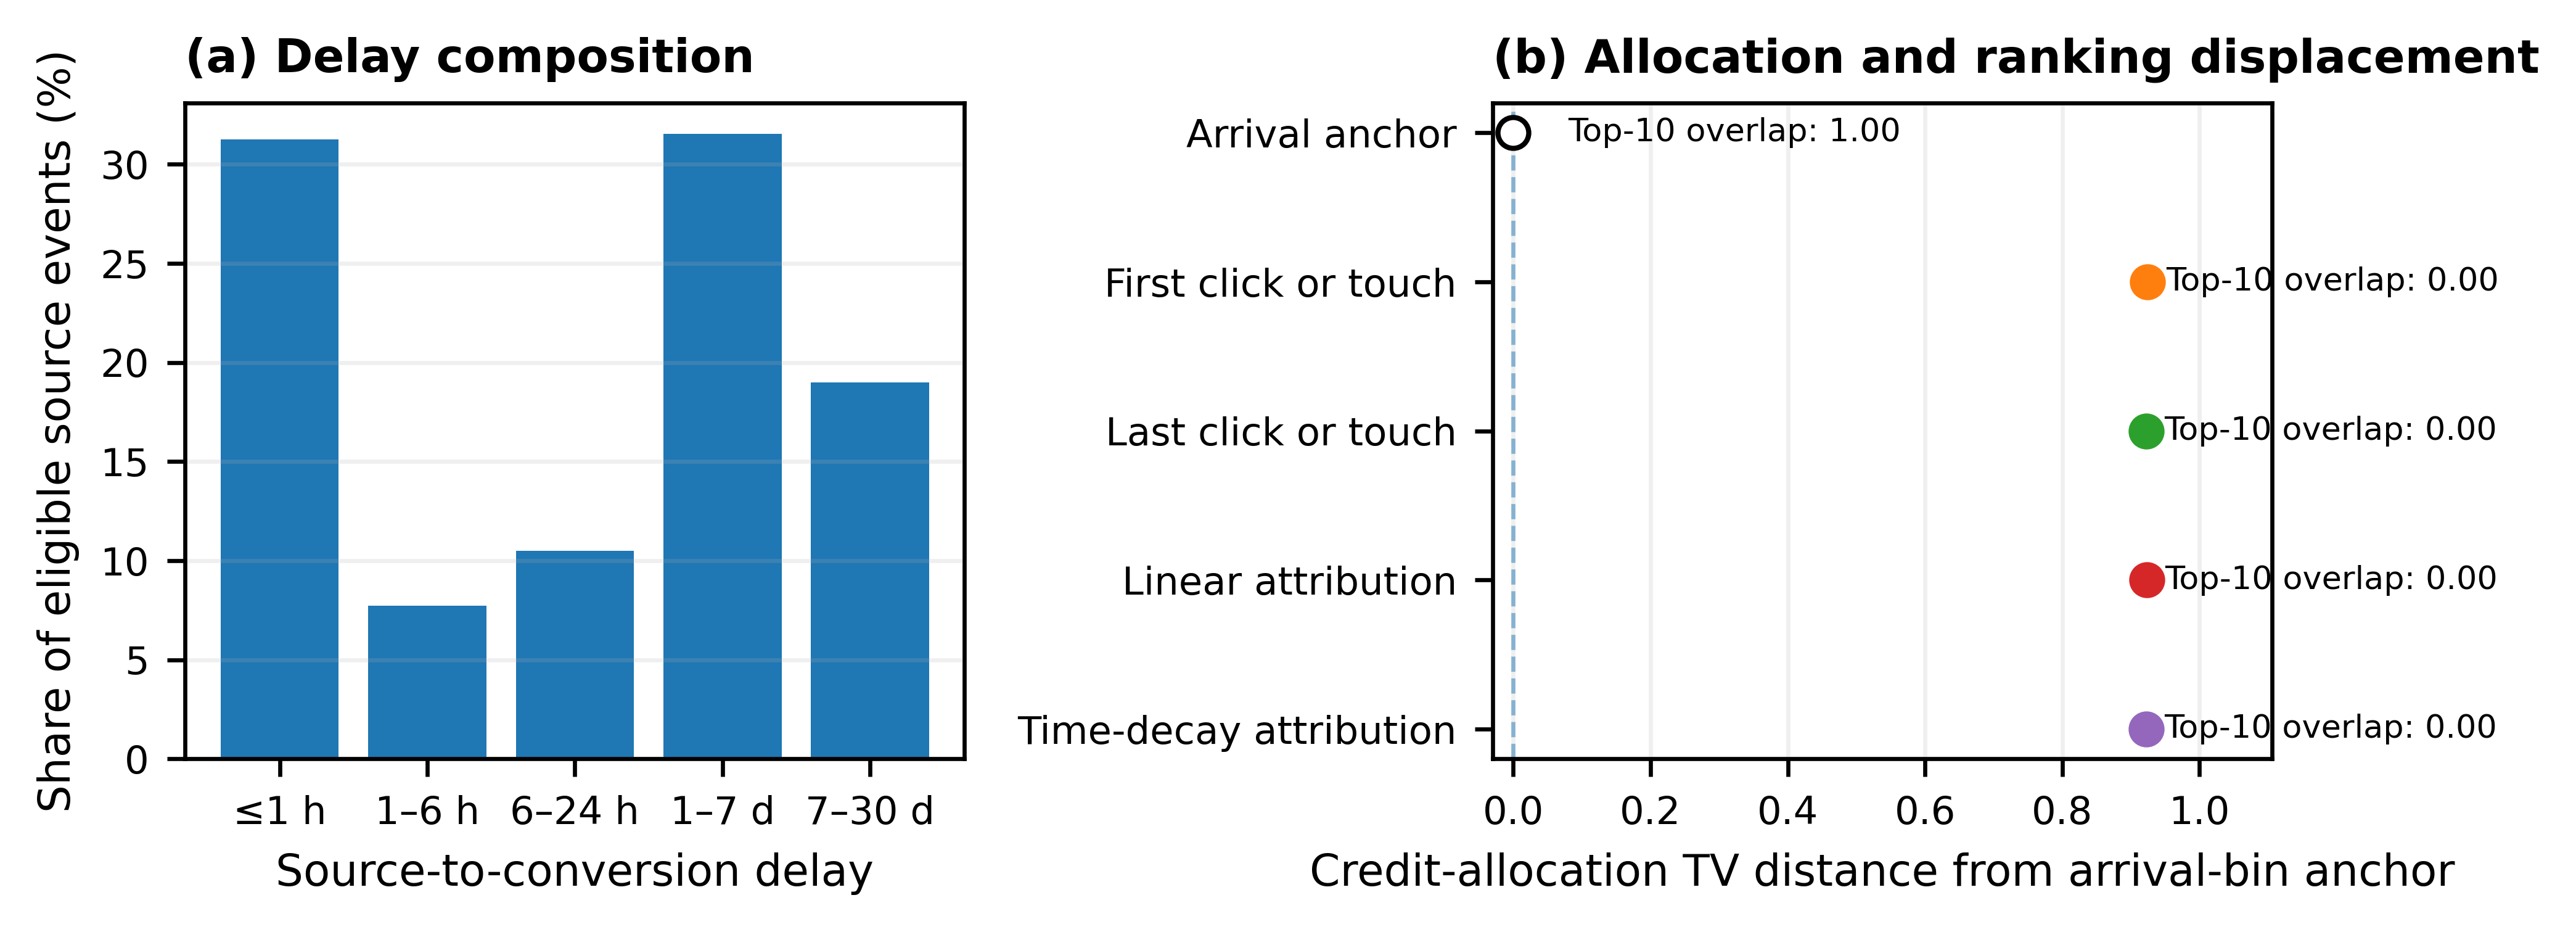

In [3]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

figures = prefer_outputs(find_files(['outputs/**/figures/**/*.png']))
display(Markdown(f'Found `{len(figures)}` PNG figure files. Showing selected embedded figures.'))
show_images(figures, limit=4)


In [4]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

ROOT = Path('..').resolve()
PROJECT = ROOT.name

def rel(path):
    return path.relative_to(ROOT).as_posix()

def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})

def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/full/' in s or 'exp4_full' in s:
            value -= 100
        if '/outputs/fast/' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, s)
    return sorted(paths, key=score)

def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))

def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))

logs = find_files(['runlogs/*','outputs/**/logs/*','*.log','outputs/**/checks/*'])
log_rows = [{'path': rel(p), 'size_kb': round(p.stat().st_size/1024, 1)} for p in logs[:30]]
display(Markdown(f'Found `{len(logs)}` runlog/check records.'))
display(pd.DataFrame(log_rows))
if not csvs:
    display(Markdown('Warning: no summary/table CSV detected under outputs/.'))
if not figures:
    display(Markdown('Warning: no figure PNG detected under outputs/.'))
display(Markdown('This notebook only reads existing outputs; no experiment entrypoint was executed.'))


Found `14` runlog/check records.

,path,size_kb
0,outputs/code_check/checks/code_check_report.csv,1.7
1,outputs/code_check/checks/code_check_report.md,1.8
2,outputs/fast/checks/code_check_report.csv,5.0
3,outputs/fast/checks/code_check_report.md,4.9
4,outputs/fast/checks/exp2_self_check_report.md,17.4
5,outputs/fast/checks/exp2_self_check_results.csv,20.2
6,outputs/fast/checks/figure_table_repair_core_h...,3.4
7,outputs/fast/checks/figure_table_repair_core_h...,3.5
8,outputs/fast/checks/figure_table_repair_regres...,0.2
9,outputs/full/checks/code_check_report.csv,5.9


This notebook only reads existing outputs; no experiment entrypoint was executed.